# Mohr-Coulomb Validation — Embedded Crack with NCP Contact

Biaxial compression on a unit square with an embedded (non-boundary-intersecting) crack.
The background stress state is carried entirely by **s0/w0 offsets** — the solver computes
only the perturbation.  Two test cases validate the NCP formulation against the classical
Mohr-Coulomb criterion:

1. **Locked** (θ outside the failure zone): perturbation is zero, crack stays closed.
2. **Sliding** (θ inside the failure zone): NCP releases, crack slides.

## 1. Imports

In [1]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '4')

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from skfem.models.elasticity import lame_parameters

from poroelasticity import CGPoroelastostatics, CrackMeshBuilder
from poroelasticity.cg_dashboard import CGPoroelasticDashboard

import solve_nivp
from solve_nivp.ncp_contact import build_dynamic_ncp_contact

print(f"solve_nivp version: {getattr(solve_nivp, '__version__', 'dev')}")
print('Imports OK')

solve_nivp version: dev
Imports OK


## 2. Configuration

`ALPHA_BIOT = 0` decouples fluid and solid — pure elastodynamics.  High bulk viscous
damping (`BULK_MU_V`, `BULK_LAM_V`) overdamps the system so the Radau IIA time-stepping
is effectively quasi-static.  The crack is embedded at `(0.5, 0.5)` with length 0.4,
well inside the unit square.

In [2]:
NU          = 0.25
G_SHEAR     = 22.0e3                # MPa
E_YOUNG     = 2.0 * G_SHEAR * (1.0 + NU)
ALPHA_BIOT  = 0.0
BETA_FLUID  = 8.5e-5
ETA_FLUID   = 2.0e-18 / 3600.0
K_PERM      = 1.0e-15 * 1.0e-6
DENSITY     = 1.0
BULK_MU_V   = 1.0e6
BULK_LAM_V  = 1.0e6
SCALE_L     = 1.0
SCALE_EPS   = 1.0e-3

XMIN, XMAX = 0.0, 1.0
YMIN, YMAX = 0.0, 1.0
N_ELEM     = 10

CRACK_X0     = 0.5
CRACK_Y0     = 0.5
CRACK_LENGTH = 0.4

SIGMA_RIGHT = 10.0                  # MPa, compression positive
SIGMA_TOP   = 30.0

MU = 0.3

TMAX    = 1.0
H_FIXED = 0.1

LAM, MU_LAME = lame_parameters(E_YOUNG, NU)
PARAMS = (MU_LAME, LAM, ALPHA_BIOT, BETA_FLUID, K_PERM / ETA_FLUID)

S1 = max(SIGMA_RIGHT, SIGMA_TOP)
S3 = min(SIGMA_RIGHT, SIGMA_TOP)

print(f"Domain:  [{XMIN},{XMAX}] × [{YMIN},{YMAX}],  N_ELEM = {N_ELEM}")
print(f"Crack:   centre=({CRACK_X0},{CRACK_Y0}), length={CRACK_LENGTH}")
print(f"Loading: σ_right={SIGMA_RIGHT}, σ_top={SIGMA_TOP}  →  σ₁={S1}, σ₃={S3}")
print(f"Friction: μ = {MU}")
print(f"Damping: bulk_mu_v={BULK_MU_V:.1e}, bulk_lam_v={BULK_LAM_V:.1e}")
print(f"Time:    tmax={TMAX}, h={H_FIXED}")

Domain:  [0.0,1.0] × [0.0,1.0],  N_ELEM = 10
Crack:   centre=(0.5,0.5), length=0.4
Loading: σ_right=10.0, σ_top=30.0  →  σ₁=30.0, σ₃=10.0
Friction: μ = 0.3
Damping: bulk_mu_v=1.0e+06, bulk_lam_v=1.0e+06
Time:    tmax=1.0, h=0.1


## 3. Analytical Mohr-Coulomb

On a plane at angle θ from σ₁ (compression positive):

$$\sigma_N(\theta) = \frac{\sigma_1 + \sigma_3}{2} + \frac{\sigma_1 - \sigma_3}{2}\cos 2\theta, \qquad
\tau(\theta) = \frac{\sigma_1 - \sigma_3}{2}\sin 2\theta$$

Coulomb failure (cohesionless): $|\tau| = \mu\,\sigma_N$.

The **failure plane angle** $\theta_{\mathrm{crit}} = \tfrac{1}{2}\arctan(1/\mu)$ maximises
the ratio $|\tau|/\mu\sigma_N$ over all orientations.  When the Mohr circle extends past
the Coulomb envelope — as it does here — there is a **range** of orientations
$[\theta_{\mathrm{onset}},\,\theta_{\mathrm{upper}}]$ where $|\tau| > \mu\sigma_N$.

**Angle convention:** `CrackMeshBuilder` parameterizes `crack_theta` as the angle of the
crack *line* measured counter-clockwise from the y-axis.  With σ₁ vertical, a Mohr angle
θ from σ₁ corresponds to `crack_theta = π/2 − θ`.

In [3]:
phi = np.arctan(MU)
theta_crit = 0.5 * np.arctan(1.0 / MU)

a_mc = (S1 - S3) / 2
R_mc = a_mc * np.sqrt(1 + MU**2)
sin_arg = MU * (S1 + S3) / (2 * R_mc)
theta_onset = 0.5 * (phi + np.arcsin(sin_arg))
theta_upper = 0.5 * (phi + np.pi - np.arcsin(sin_arg))

THETA_LOCKED  = np.radians(20.0)
THETA_SLIDING = np.radians(45.0)

def mohr_tractions(theta):
    sigma_N = (S1 + S3) / 2 + (S1 - S3) / 2 * np.cos(2 * theta)
    tau     = (S1 - S3) / 2 * np.sin(2 * theta)
    return sigma_N, tau

sN_locked,  tau_locked  = mohr_tractions(THETA_LOCKED)
sN_sliding, tau_sliding = mohr_tractions(THETA_SLIDING)

CRACK_THETA_LOCKED  = np.pi / 2 - THETA_LOCKED
CRACK_THETA_SLIDING = np.pi / 2 - THETA_SLIDING

print(f"θ_crit  = {np.degrees(theta_crit):.2f}° (failure plane angle)")
print(f"Failure zone: [{np.degrees(theta_onset):.2f}°, {np.degrees(theta_upper):.2f}°]")
print(f"φ = arctan(μ) = {np.degrees(phi):.2f}°")
print()
print(f"Locked test  (θ = {np.degrees(THETA_LOCKED):.0f}° < θ_onset = {np.degrees(theta_onset):.1f}°):")
print(f"  σ_N = {sN_locked:.2f},  τ = {tau_locked:.2f},  μσ_N = {MU*sN_locked:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_locked)/(MU*sN_locked):.4f}  (< 1 → locked)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_LOCKED):.1f}°")
print()
print(f"Sliding test (θ = {np.degrees(THETA_SLIDING):.0f}° ∈ failure zone):")
print(f"  σ_N = {sN_sliding:.2f},  τ = {tau_sliding:.2f},  μσ_N = {MU*sN_sliding:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_sliding)/(MU*sN_sliding):.4f}  (> 1 → sliding)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_SLIDING):.1f}°")

θ_crit  = 36.65° (failure plane angle)
Failure zone: [25.89°, 80.81°]
φ = arctan(μ) = 16.70°

Locked test  (θ = 20° < θ_onset = 25.9°):
  σ_N = 27.66,  τ = 6.43,  μσ_N = 8.30
  |τ|/μσ_N = 0.7746  (< 1 → locked)
  crack_theta = 70.0°

Sliding test (θ = 45° ∈ failure zone):
  σ_N = 20.00,  τ = 10.00,  μσ_N = 6.00
  |τ|/μσ_N = 1.6667  (> 1 → sliding)
  crack_theta = 45.0°


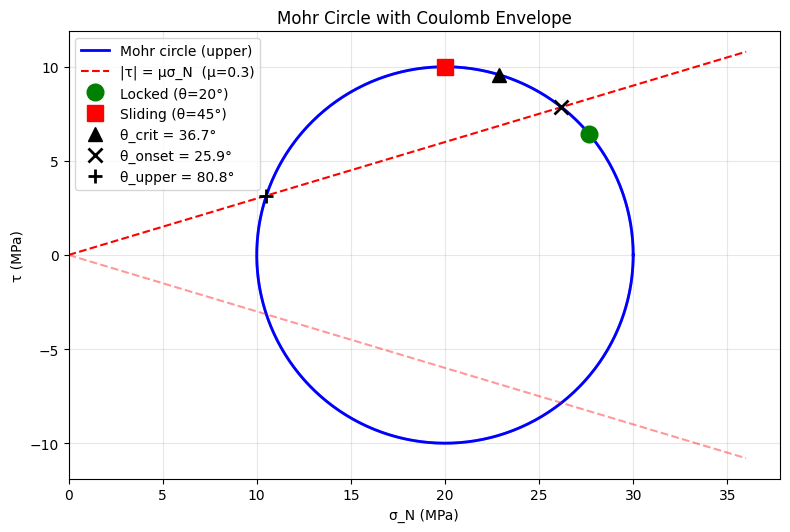

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

theta_range = np.linspace(0, np.pi, 300)
sN_range, tau_range = mohr_tractions(theta_range)
ax.plot(sN_range, tau_range, 'b-', lw=2, label='Mohr circle (upper)')
ax.plot(sN_range, -tau_range, 'b-', lw=2, alpha=0.4)

sN_env = np.linspace(0, S1 * 1.2, 100)
ax.plot(sN_env, MU * sN_env, 'r--', lw=1.5, label=f'|τ| = μσ_N  (μ={MU})')
ax.plot(sN_env, -MU * sN_env, 'r--', lw=1.5, alpha=0.4)

ax.plot(sN_locked, tau_locked, 'go', ms=12, zorder=5,
        label=f'Locked (θ={np.degrees(THETA_LOCKED):.0f}°)')
ax.plot(sN_sliding, tau_sliding, 'rs', ms=12, zorder=5,
        label=f'Sliding (θ={np.degrees(THETA_SLIDING):.0f}°)')

sN_crit, tau_crit = mohr_tractions(theta_crit)
ax.plot(sN_crit, tau_crit, 'k^', ms=10, zorder=5,
        label=f'θ_crit = {np.degrees(theta_crit):.1f}°')

sN_on, tau_on = mohr_tractions(theta_onset)
sN_up, tau_up = mohr_tractions(theta_upper)
ax.plot(sN_on, tau_on, 'kx', ms=10, mew=2, zorder=5,
        label=f'θ_onset = {np.degrees(theta_onset):.1f}°')
ax.plot(sN_up, tau_up, 'k+', ms=10, mew=2, zorder=5,
        label=f'θ_upper = {np.degrees(theta_upper):.1f}°')

ax.set_xlabel('σ_N (MPa)')
ax.set_ylabel('τ (MPa)')
ax.set_title('Mohr Circle with Coulomb Envelope')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## 4. Build Conforming Mesh (Locked Test, θ = 20°)

In [5]:
builder = CrackMeshBuilder(
    XMIN, XMAX, YMIN, YMAX, N_ELEM,
    crack_theta=CRACK_THETA_LOCKED,
    crack_x0=CRACK_X0, crack_y0=CRACK_Y0,
    crack_length=CRACK_LENGTH,
    element_type='tri', conforming=True,
    verbose=True,
)
mesh, el_p, el_u, crack, h_mesh = builder.build()
print(f"h ≈ {h_mesh:.4f},  elements = {mesh.nelements},  vertices = {mesh.p.shape[1]}")


Conforming tri mesh: 268 elements, h=0.1000


[RobustCrackGenerator] KDTree facet query: 48 candidates, 18 good (both endpoints within 1.0h, strict)
[RobustCrackGenerator] Facet hits: 30 | t-range=[0.000, 1.000]
[RobustCrackGenerator] 32 good facets (BOTH endpoints within h), 30 direct hits
[RobustCrackGenerator] Final: 32 good facets (no connectors)
[RobustCrackGenerator] TRI mesh detected
[RobustCrackGenerator] Diagonal crack detected
[EXTEND] Starting with 4 facets, t-range=[0.125000, 0.875000]
[EXTEND] Global t-range=[0.000000, 1.000000]
[EXTEND] Initial frontier (start): 26 facets
[EXTEND] Iteration 1: adding 4 facets towards start
[EXTEND] Iteration 1: adding 4 facets towards end
[EXTEND] Final: 12 facets, t-range=[0.001109, 0.998891]
[EXTEND] Starting with 12 facets, t-range=[0.001109, 0.998891]
[EXTEND] Global t-range=[0.000000, 1.000000]
[EXTEND] Initial frontier (start): 18 facets
[EXTEND] Final: 12 facets, t-range=[0.001109, 0.998891]
[RobustCrackGenerator] Articulation points: 2, removable: 10
[RobustCrackGenerator] Du

## 5. Assemble CG Solver

`crack_law='nonsmooth'` sets K = I (pure displacement-jump evaluator).
`rotate_crack_to_nt=True` separates normal and tangential DOFs at the crack interface.
Roller BCs: left (v₁ = 0), bottom (v₂ = 0).  No traction BCs — the entire background
stress is carried by s0/w0 offsets.

In [6]:
bc = {
    'v1': {'left': 0.0},
    'v2': {'bottom': 0.0},
    'dp_rate': {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0},
}

poro = CGPoroelastostatics(
    mesh=mesh,
    element_p=el_p,
    element_u=el_u,
    params=PARAMS,
    crack=crack,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc,
    P_scale=None,
    verbose=True,
    free_memory=False,
    enforcement_type='nodal',
    apply_transform=True,
    include_taylor=False,
    include_hessian=False,
    include_sbm=False,
    density=DENSITY,
    crack_law='nonsmooth',
    rotate_crack_to_nt=True,
    bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
)

print(f"ndofs = {poro.ndofs}")
print(f"  Np = {poro.basis_p.N},  Nu = {poro.basis_u.N}")
print(f"  n_lambda_q = {poro.n_lambda_q},  n_lambda_sigma = {poro.n_lambda_sigma}")
print(f"  crack_law = nonsmooth,  rotated_to_nt = {poro._transform_info.get('rotated_to_nt')}")

Mesh split along crack:
  Original: 155 vertices, 268 elements
  Split: 160 vertices, 268 elements
  Crack facets: 4 plus, 4 minus
  Projected 0 / 16 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 4
  Number of DOFs: 160
  Size: 1152 B
  Projected 0 / 16 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7cbc78332b10>
  Projected 0 / 16 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 4
  Number of DOFs: 856
  Size: 6144 B
  Projected 0 / 16 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7cbc78333a10>
SBM geometry cache: 64 QPs pre-computed in 1.0 ms
Crack interface assembled (Spring law + SBM corrections):
  Robin T = 1.00e+02 (dimensionless: 7.15e-05)
  Spring k_n = None (dimensionless: 1.00e+00)
  Spring k_t = None (dimensionless: 1.00e+00)
  Enforcement type: nod

Transform applied (column only): y_old = T_inv @ z_new
  New: [p_b(150), u_b(836), {{p}}(5), [[p]](5), {{u_n}}(5), {{u_t}}(5), [[u_n]](5), [[u_t]](5), {{λ_q}}(5), [[λ_q]](5), {{σ_n}}(5), {{τ}}(5), [[σ_n]](5), [[τ]](5)]
DOFs: pressure=160, displacement=856, total=1046
  Bulk Kelvin–Voigt: mu_v=1.00e+06, lam_v=1.00e+06 (dimless: mu_v_d=3.2086e+05, lam_v_d=3.2086e+05)
ndofs = 1046
  Np = 160,  Nu = 856
  n_lambda_q = 5,  n_lambda_sigma = 10
  crack_law = nonsmooth,  rotated_to_nt = True


## 6. Projection and Dynamic System

`strip_multiplier_dynamics()` zeros the multiplier rows of `M` so the algebraic
projection owns them.  `build_projection()` builds the constraint projection.
`build_first_order_dynamic_system()` lifts to descriptor form `A_dyn · ẋ = rhs(t, x)`.

In [7]:
poro.strip_multiplier_dynamics()
projection, meta = poro.build_projection()

dyn = poro.build_first_order_dynamic_system(meta, density=DENSITY)

A_dyn          = dyn['A']
rhs_dyn        = dyn['rhs']
rhs_jac_dyn    = dyn['rhs_jac']
velocity_slice = dyn['velocity_slice']
n_base         = dyn['n_base']
comp_slices    = dyn['component_slices']
nl_atol_dyn    = dyn['nl_atol_per_block']

Np = poro.basis_p.N
Nu = poro.basis_u.N

print(f"n_base = {n_base},  |x| = {A_dyn.shape[0]},  nnz(A_dyn) = {A_dyn.nnz}")
print(f"velocity_slice = {velocity_slice}")
print(f"component_slices: {len(comp_slices)} blocks")

build_projection():
  Flux constraint:     C_q shape=(10, 1016)
  Traction constraint: C_s shape=(20, 1016)
  Projection type:     AlgebraicConstraintProjection
  Component slices:    13 blocks
n_base = 1046,  |x| = 1902,  nnz(A_dyn) = 7638
velocity_slice = slice(1046, np.int32(1902), None)
component_slices: 18 blocks


### 6a. Descriptor Pencil Diagnostics

In [8]:
A_csr = A_dyn.tocsr()
J_csr = rhs_jac_dyn(0.0, np.zeros(A_dyn.shape[0])).tocsr()

row_p   = slice(0, Np)
row_u   = slice(Np, Np + Nu)
row_lam = slice(Np + Nu, n_base)
row_mom = slice(n_base, n_base + Nu)

def fro(block):
    return float(sp.linalg.norm(block, 'fro')) if block.nnz else 0.0

print("=== A_dyn block norms (descriptor mass) ===")
print(f"  ||A[p, z]||   = {fro(A_csr[row_p, :n_base]):.3e}")
print(f"  ||A[kin, z]||  = {fro(A_csr[row_u, :n_base]):.3e}")
print(f"  ||A[lam, :]||  = {fro(A_csr[row_lam, :]):.3e}  (expect 0 — stripped)")
print(f"  ||A[mom, v]||  = {fro(A_csr[row_mom, n_base:]):.3e}  (FE inertia)")
print()
print("=== J_dyn block norms (RHS Jacobian) ===")
print(f"  ||J[mom, z]||  = {fro(J_csr[row_mom, :n_base]):.3e}  (stiffness)")
print(f"  ||J[mom, v]||  = {fro(J_csr[row_mom, n_base:]):.3e}  (damping)")

=== A_dyn block norms (descriptor mass) ===
  ||A[p, z]||   = 6.325e+00
  ||A[kin, z]||  = 2.926e+01
  ||A[lam, :]||  = 0.000e+00  (expect 0 — stripped)


  ||A[mom, v]||  = 7.561e-02  (FE inertia)

=== J_dyn block norms (RHS Jacobian) ===
  ||J[mom, z]||  = 1.266e+02  (stiffness)
  ||J[mom, v]||  = 1.218e+08  (damping)


## 7. NCP Contact Wiring

Build extraction matrices D (velocity jump) and B (traction distribution) directly
from `_transform_info` offsets — the same approach verified in the work-conjugacy check
of `dynamic_verification_crack.ipynb` Section 11.

With `rotate_crack_to_nt=True`, the transformed state exposes `[[u_n]]` and `[[u_t]]`
as contiguous blocks at known offsets.

- **D** = rows of `T_u` at `[[u]]` positions → extracts velocity jumps `[[v_n]], [[v_t]]`
- **B** = negated columns of `A` at `[[λ_σ]]` positions → distributes tractions

Work-conjugacy `B = -(h/2) D^T` holds exactly for mesh-aligned cracks.
Diagonal cracks have non-uniform surrogate facet weights so the scalar
relationship degrades, but B = D^T M_Γ still factors through a diagonal
interface mass (the NCP does not require the scalar form).

In [9]:
info = poro._transform_info
n_c  = int(poro.n_lambda_q)
dim  = int(poro.dim)

lam_s_sl = meta['lam_s_sl']

off_jmpu  = info['off_jmpu']
n_iu      = info['n_intf_u']
off_jmpls = info['off_jmpls']
n_lsig    = info['n_lam_sig']

# With rotate_crack_to_nt: [[u_n]](n_c) then [[u_t]](n_c)
jmpu_n_indices = np.arange(off_jmpu, off_jmpu + n_c)
jmpu_t_indices = np.arange(off_jmpu + n_c, off_jmpu + n_iu)
jmpu_all = np.concatenate([jmpu_n_indices, jmpu_t_indices])

jmpls_cols = np.arange(off_jmpls, off_jmpls + n_lsig)

print(f"Interface nodes:  n_c = {n_c}")
print(f"[[u_n]] indices:  {jmpu_n_indices[0]}..{jmpu_n_indices[-1]}")
print(f"[[u_t]] indices:  {jmpu_t_indices[0]}..{jmpu_t_indices[-1]}")
print(f"[[λ_σ]] columns:  {jmpls_cols[0]}..{jmpls_cols[-1]}")

T_u_mat = dyn['T_u']
u_idx   = dyn['u_state_indices']
jmpu_local = np.searchsorted(u_idx, jmpu_all)
assert np.all(u_idx[jmpu_local] == jmpu_all), "[[u]] DOFs not found in u_state"
D = T_u_mat[jmpu_local, :].tocsr()

R_v = dyn.get('R_v')
A_csr = poro.A.tocsr()
B_u = -(A_csr[Np:Np + Nu, :][:, jmpls_cols]).tocsr()
if R_v is not None:
    B_u = (R_v @ B_u).tocsr()

dirichlet_local = np.array(
    [d - Np for d in np.asarray(getattr(poro, '_dirichlet_dof_set', []), dtype=int)
     if Np <= d < Np + Nu],
    dtype=int,
)
if dirichlet_local.size:
    B_u = B_u.tolil()
    B_u[dirichlet_local, :] = 0.0
    B_u = B_u.tocsr()

scale = -h_mesh / 2.0
err_wc = sp.linalg.norm(B_u - scale * D.T) / sp.linalg.norm(B_u)
print(f"\nWork-conjugacy check: ||B - (-h/2)D^T|| / ||B|| = {err_wc:.2e}")
print(f"  (expect < 1e-12, h = {h_mesh:.6f}, scale = {scale:.6f})")

# NCP reaction DOFs ordered per-block: [r_n_0, r_t_0, r_n_1, r_t_1, ...]
perm = [idx for k in range(n_c) for idx in (k, n_c + k)]
B_u_perm = B_u[:, perm].tocsr()

contacts = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c + k],
        'mu': MU,
        'e': 0.0,
    }
    for k in range(n_c)
]

print(f"\nContact blocks: {len(contacts)}")

Interface nodes:  n_c = 5
[[u_n]] indices:  1006..1010
[[u_t]] indices:  1011..1015
[[λ_σ]] columns:  1036..1045

Work-conjugacy check: ||B - (-h/2)D^T|| / ||B|| = 3.78e-01
  (expect < 1e-12, h = 0.100000, scale = -0.050000)

Contact blocks: 5


In [10]:
n_aug_phys = A_dyn.shape[0]
n_extract = 2 * n_c

rows_gap = np.arange(n_extract)
cols_gap = jmpu_all
gap_extract_dyn = sp.csr_matrix(
    (np.ones(n_extract), (rows_gap, cols_gap)),
    shape=(n_extract, n_aug_phys),
)

vel_extract_dyn = sp.hstack(
    [sp.csr_matrix((n_extract, n_base)), D],
    format='csr',
)

B_dyn = sp.vstack(
    [sp.csr_matrix((n_base, B_u_perm.shape[1])), B_u_perm],
    format='csr',
)

print(f"gap_extract_dyn shape: {gap_extract_dyn.shape}")
print(f"vel_extract_dyn shape: {vel_extract_dyn.shape}")
print(f"B_dyn shape:           {B_dyn.shape}")

gap_extract_dyn shape: (10, 1902)
vel_extract_dyn shape: (10, 1902)
B_dyn shape:           (1902, 10)


In [11]:
sigma_N_locked, tau_locked_val = mohr_tractions(THETA_LOCKED)

get_s0 = lambda y: sigma_N_locked
get_w0 = lambda y, k: np.array([tau_locked_val])

flux_constraint = meta['constraints'][0]

n_lam_s_dim = int(lam_s_sl.stop - lam_s_sl.start)
zero_lam_s = {
    'g': lambda zf, *_a, _n=n_lam_s_dim: np.zeros(_n),
    'dg_dy': lambda zf, *_a, _n=n_lam_s_dim: np.zeros((_n, _n)),
    'y_slice': lam_s_sl,
    'q_slice': lam_s_sl,
}

cs = build_dynamic_ncp_contact(
    A=A_dyn,
    rhs_smooth=rhs_dyn,
    rhs_jac=rhs_jac_dyn,
    y0=np.zeros(A_dyn.shape[0]),
    contacts=contacts,
    B=B_dyn,
    gap_extract=gap_extract_dyn,
    vel_extract=vel_extract_dyn,
    constraints=[flux_constraint, zero_lam_s],
    component_slices=comp_slices,
    offset_coupling_mode='constitutive_shift',
    get_s0=get_s0,
    get_w0=get_w0,
    ncp_type='fischer_burmeister',
    normal_r='auto',
    friction_r='auto',
    inactive_handling='ncp',
)

print(f"Augmented system size: {cs.A.shape[0]}")
print(f"  Physics DOFs: {A_dyn.shape[0]}")
print(f"  Reaction DOFs: {cs.A.shape[0] - A_dyn.shape[0]}")
print(f"  Component slices: {len(cs.component_slices)}")

Augmented system size: 1912
  Physics DOFs: 1902
  Reaction DOFs: 10
  Component slices: 19


## 8. Initial Condition

Zero perturbation everywhere — the background stress is entirely in s0/w0.

In [12]:
y0_locked = cs.y0.copy()

print(f"|y0| = {np.linalg.norm(y0_locked):.4e}")
print(f"  (should be ~0 — pure perturbation problem)")

|y0| = 0.0000e+00
  (should be ~0 — pure perturbation problem)


## 9. Solve — Locked Test (θ = 20° < θ_onset)

The resolved shear stress is below the Coulomb threshold, so the crack should remain
locked: zero perturbation displacement, zero slip.

In [13]:
n_aug_locked = cs.y0.size
n_phys_locked = A_dyn.shape[0]

nl_atol_locked = np.full(n_aug_locked, 1e-8)
nl_rtol_locked = np.full(n_aug_locked, 1e-6)
nl_atol_locked[n_phys_locked:] = 1e-10
nl_rtol_locked[n_phys_locked:] = 0.0

solver_opts_locked = dict(cs.solver_opts)
solver_opts_locked.pop('cold_start_slices', None)
solver_opts_locked['damped_step_fraction'] = 1.0
solver_opts_locked['diagonal_regularization'] = 0.0
solver_opts_locked.update(
    tol=1e-8,
    max_iter=500,
    rhs_jac=cs.rhs_jac,
    linear_solver='petsc',
)

integrator_opts_locked = dict(cs.integrator_opts)
integrator_opts_locked.update({'stages': 2, 'use_coupled_newton': True})

print(f"Solving locked test: Radau IIA s=2, h={H_FIXED}, tmax={TMAX}")

t_locked, y_locked, h_locked, fk_locked, info_locked = solve_nivp.solve_ivp_ns(
    fun=cs.rhs,
    t_span=(0, TMAX),
    y0=y0_locked,
    method='radau_iia',
    integrator_opts=integrator_opts_locked,
    projection=cs.projection,
    solver='semismooth_newton',
    projection_opts={'rhok': 1.0, 'component_slices': cs.component_slices},
    solver_opts=solver_opts_locked,
    adaptive=False, h0=H_FIXED,
    nl_atol=nl_atol_locked, nl_rtol=nl_rtol_locked,
    component_slices=cs.component_slices,
    verbose=True,
    A=cs.A,
    dae_var_weight='auto',
    active_set_filter=False,
)

print(f"Done: {len(t_locked)} steps, t_final = {t_locked[-1]:.4e}")

n_aug = cs.A.shape[0]
n_phys = A_dyn.shape[0]
y_final = y_locked[-1]

u_pert_max = np.max(np.abs(y_final[:n_base]))
v_pert_max = np.max(np.abs(y_final[n_base:n_phys]))
r_max      = np.max(np.abs(y_final[n_phys:]))

print(f"\nPerturbation at t_final:")
print(f"  max |z_perturbation| = {u_pert_max:.3e}")
print(f"  max |v_perturbation| = {v_pert_max:.3e}")
print(f"  max |reaction|       = {r_max:.3e}")
print(f"  LOCKED = {u_pert_max < 1e-8}")

Solving locked test: Radau IIA s=2, h=0.1, tmax=1.0


Done: 11 steps, t_final = 1.0000e+00

Perturbation at t_final:
  max |z_perturbation| = 0.000e+00
  max |v_perturbation| = 0.000e+00
  max |reaction|       = 0.000e+00
  LOCKED = True


### 9a. Dashboard — Locked

Full-field contour plots of the perturbation.  Everything should be near-zero.

In [14]:
z_locked = y_locked[:, :n_base]

fields_locked = poro.sol_to_fields_dict_with_dimensions(
    np.asarray(t_locked),
    z_locked.T,
    use_taylor_correction=False,
    constrained_l2=False,
)
fields_locked['y_raw'] = z_locked.T
fields_locked['t_raw'] = np.asarray(t_locked)

dashboard_locked = CGPoroelasticDashboard(poro, fields_locked, levels=40)
dashboard_locked.show()

## 10. Solve — Sliding Test (θ = 45° ∈ failure zone)

Rebuild the mesh at the sliding angle.  The resolved shear stress exceeds the Coulomb
threshold, so the NCP should release and the crack should slide.

In [15]:
builder_s = CrackMeshBuilder(
    XMIN, XMAX, YMIN, YMAX, N_ELEM,
    crack_theta=CRACK_THETA_SLIDING,
    crack_x0=CRACK_X0, crack_y0=CRACK_Y0,
    crack_length=CRACK_LENGTH,
    element_type='tri', conforming=True,
    verbose=True,
)
mesh_s, el_p_s, el_u_s, crack_s, h_mesh_s = builder_s.build()

bc_s = {
    'v1': {'left': 0.0},
    'v2': {'bottom': 0.0},
    'dp_rate': {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0},
}

poro_s = CGPoroelastostatics(
    mesh=mesh_s,
    element_p=el_p_s,
    element_u=el_u_s,
    params=PARAMS,
    crack=crack_s,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc_s,
    P_scale=None,
    verbose=True,
    free_memory=False,
    enforcement_type='nodal',
    apply_transform=True,
    include_taylor=False,
    include_hessian=False,
    include_sbm=False,
    density=DENSITY,
    crack_law='nonsmooth',
    rotate_crack_to_nt=True,
    bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
)

poro_s.strip_multiplier_dynamics()
projection_s, meta_s = poro_s.build_projection()
dyn_s = poro_s.build_first_order_dynamic_system(meta_s, density=DENSITY)

A_dyn_s          = dyn_s['A']
rhs_dyn_s        = dyn_s['rhs']
rhs_jac_dyn_s    = dyn_s['rhs_jac']
velocity_slice_s = dyn_s['velocity_slice']
n_base_s         = dyn_s['n_base']
comp_slices_s    = dyn_s['component_slices']

Np_s = poro_s.basis_p.N
Nu_s = poro_s.basis_u.N

print(f"Sliding mesh: {mesh_s.nelements} elements, {mesh_s.p.shape[1]} vertices")
print(f"n_base = {n_base_s}, |x| = {A_dyn_s.shape[0]}")


Conforming tri mesh: 260 elements, h=0.1000
[RobustCrackGenerator] KDTree facet query: 46 candidates, 17 good (both endpoints within 1.0h, strict)
[RobustCrackGenerator] Facet hits: 30 | t-range=[0.000, 1.000]
[RobustCrackGenerator] 32 good facets (BOTH endpoints within h), 30 direct hits
[RobustCrackGenerator] Final: 32 good facets (no connectors)
[RobustCrackGenerator] TRI mesh detected
[RobustCrackGenerator] Diagonal crack detected
[EXTEND] Starting with 4 facets, t-range=[0.125000, 0.875000]
[EXTEND] Global t-range=[0.000000, 1.000000]
[EXTEND] Initial frontier (start): 26 facets
[EXTEND] Iteration 1: adding 5 facets towards start
[EXTEND] Iteration 1: adding 4 facets towards end
[EXTEND] Final: 13 facets, t-range=[0.000000, 0.946835]
[EXTEND] Starting with 13 facets, t-range=[0.000000, 0.946835]
[EXTEND] Global t-range=[0.000000, 1.000000]
[EXTEND] Initial frontier (start): 17 facets
[EXTEND] Final: 13 facets, t-range=[0.000000, 0.946835]
[RobustCrackGenerator] Articulation point

  Projected 0 / 16 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 4
  Number of DOFs: 156
  Size: 1152 B
  Projected 0 / 16 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7cbc32ffdfd0>
  Projected 0 / 16 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 4
  Number of DOFs: 832
  Size: 6144 B
  Projected 0 / 16 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7cbc32ffd5d0>
SBM geometry cache: 64 QPs pre-computed in 1.4 ms
Crack interface assembled (Spring law + SBM corrections):
  Robin T = 1.00e+02 (dimensionless: 7.15e-05)
  Spring k_n = None (dimensionless: 1.00e+00)
  Spring k_t = None (dimensionless: 1.00e+00)
  Enforcement type: nodal
Nodal enforcement: 5 interface node pairs (2×5 = 10 flux DOFs)
Augmented system assembled: 1018 DOFs
  = 156 (p) + 832 (u) + 2×5

In [16]:
info_s = poro_s._transform_info
n_c_s  = int(poro_s.n_lambda_q)

lam_s_sl_s = meta_s['lam_s_sl']

off_jmpu_s  = info_s['off_jmpu']
n_iu_s      = info_s['n_intf_u']
off_jmpls_s = info_s['off_jmpls']
n_lsig_s    = info_s['n_lam_sig']

jmpu_n_idx_s = np.arange(off_jmpu_s, off_jmpu_s + n_c_s)
jmpu_t_idx_s = np.arange(off_jmpu_s + n_c_s, off_jmpu_s + n_iu_s)
jmpu_all_s   = np.concatenate([jmpu_n_idx_s, jmpu_t_idx_s])
jmpls_cols_s = np.arange(off_jmpls_s, off_jmpls_s + n_lsig_s)

T_u_s = dyn_s['T_u']
u_idx_s = dyn_s['u_state_indices']
jmpu_local_s = np.searchsorted(u_idx_s, jmpu_all_s)
assert np.all(u_idx_s[jmpu_local_s] == jmpu_all_s)
D_s = T_u_s[jmpu_local_s, :].tocsr()

R_v_s = dyn_s.get('R_v')
A_csr_s = poro_s.A.tocsr()
B_u_s = -(A_csr_s[Np_s:Np_s + Nu_s, :][:, jmpls_cols_s]).tocsr()
if R_v_s is not None:
    B_u_s = (R_v_s @ B_u_s).tocsr()

dirichlet_local_s = np.array(
    [d - Np_s for d in np.asarray(getattr(poro_s, '_dirichlet_dof_set', []), dtype=int)
     if Np_s <= d < Np_s + Nu_s],
    dtype=int,
)
if dirichlet_local_s.size:
    B_u_s = B_u_s.tolil()
    B_u_s[dirichlet_local_s, :] = 0.0
    B_u_s = B_u_s.tocsr()

scale_s = -h_mesh_s / 2.0
err_wc_s = sp.linalg.norm(B_u_s - scale_s * D_s.T) / sp.linalg.norm(B_u_s)
print(f"Work-conjugacy check: ||B - (-h/2)D^T|| / ||B|| = {err_wc_s:.2e}")

perm_s = [idx for k in range(n_c_s) for idx in (k, n_c_s + k)]
B_u_perm_s = B_u_s[:, perm_s].tocsr()

contacts_s = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c_s + k],
        'mu': MU,
        'e': 0.0,
    }
    for k in range(n_c_s)
]

n_extract_s = 2 * n_c_s
n_aug_phys_s = A_dyn_s.shape[0]

gap_extract_dyn_s = sp.csr_matrix(
    (np.ones(n_extract_s), (np.arange(n_extract_s), jmpu_all_s)),
    shape=(n_extract_s, n_aug_phys_s),
)
vel_extract_dyn_s = sp.hstack(
    [sp.csr_matrix((n_extract_s, n_base_s)), D_s],
    format='csr',
)
B_dyn_s = sp.vstack(
    [sp.csr_matrix((n_base_s, B_u_perm_s.shape[1])), B_u_perm_s],
    format='csr',
)

sigma_N_sliding, tau_sliding_val = mohr_tractions(THETA_SLIDING)

get_s0_s = lambda y: sigma_N_sliding
get_w0_s = lambda y, k: np.array([tau_sliding_val])

flux_constraint_s = meta_s['constraints'][0]
n_lam_s_dim_s = int(lam_s_sl_s.stop - lam_s_sl_s.start)
zero_lam_s_s = {
    'g': lambda zf, *_a, _n=n_lam_s_dim_s: np.zeros(_n),
    'dg_dy': lambda zf, *_a, _n=n_lam_s_dim_s: np.zeros((_n, _n)),
    'y_slice': lam_s_sl_s,
    'q_slice': lam_s_sl_s,
}

cs_s = build_dynamic_ncp_contact(
    A=A_dyn_s,
    rhs_smooth=rhs_dyn_s,
    rhs_jac=rhs_jac_dyn_s,
    y0=np.zeros(A_dyn_s.shape[0]),
    contacts=contacts_s,
    B=B_dyn_s,
    gap_extract=gap_extract_dyn_s,
    vel_extract=vel_extract_dyn_s,
    constraints=[flux_constraint_s, zero_lam_s_s],
    component_slices=comp_slices_s,
    offset_coupling_mode='constitutive_shift',
    get_s0=get_s0_s,
    get_w0=get_w0_s,
    ncp_type='fischer_burmeister',
    normal_r='auto',
    friction_r='auto',
    inactive_handling='ncp',
)

print(f"Sliding augmented system size: {cs_s.A.shape[0]}")

Work-conjugacy check: ||B - (-h/2)D^T|| / ||B|| = 3.78e-01
Sliding augmented system size: 1860


In [17]:
n_aug_sliding = cs_s.y0.size
n_phys_sliding = A_dyn_s.shape[0]

nl_atol_sliding = np.full(n_aug_sliding, 1e-8)
nl_rtol_sliding = np.full(n_aug_sliding, 1e-6)
nl_atol_sliding[n_phys_sliding:] = 1e-10
nl_rtol_sliding[n_phys_sliding:] = 0.0

solver_opts_sliding = dict(cs_s.solver_opts)
solver_opts_sliding.pop('cold_start_slices', None)
solver_opts_sliding['damped_step_fraction'] = 1.0
solver_opts_sliding['diagonal_regularization'] = 0.0
solver_opts_sliding.update(
    tol=1e-8,
    max_iter=500,
    rhs_jac=cs_s.rhs_jac,
    linear_solver='petsc',
)

integrator_opts_sliding = dict(cs_s.integrator_opts)
integrator_opts_sliding.update({'stages': 2, 'use_coupled_newton': True})

print(f"Solving sliding test: Radau IIA s=2, h={H_FIXED}, tmax={TMAX}")

t_sliding, y_sliding, h_sliding, fk_sliding, info_sliding = solve_nivp.solve_ivp_ns(
    fun=cs_s.rhs,
    t_span=(0, TMAX),
    y0=cs_s.y0.copy(),
    method='radau_iia',
    integrator_opts=integrator_opts_sliding,
    projection=cs_s.projection,
    solver='semismooth_newton',
    projection_opts={'rhok': 1.0, 'component_slices': cs_s.component_slices},
    solver_opts=solver_opts_sliding,
    adaptive=False, h0=H_FIXED,
    nl_atol=nl_atol_sliding, nl_rtol=nl_rtol_sliding,
    component_slices=cs_s.component_slices,
    verbose=True,
    A=cs_s.A,
    dae_var_weight='auto',
    active_set_filter=False,
)

n_phys_s = A_dyn_s.shape[0]
y_final_s = y_sliding[-1]

u_pert_max_s = np.max(np.abs(y_final_s[:n_base_s]))
v_pert_max_s = np.max(np.abs(y_final_s[n_base_s:n_phys_s]))
r_max_s      = np.max(np.abs(y_final_s[n_phys_s:]))

print(f"\nDone: {len(t_sliding)} steps, t_final = {t_sliding[-1]:.4e}")
print(f"\nPerturbation at t_final:")
print(f"  max |z_perturbation| = {u_pert_max_s:.3e}")
print(f"  max |v_perturbation| = {v_pert_max_s:.3e}")
print(f"  max |reaction|       = {r_max_s:.3e}")
print(f"  SLIDING = {u_pert_max_s > 1e-8}")

Solving sliding test: Radau IIA s=2, h=0.1, tmax=1.0


/home/david/Documents/Solve_ivp_ns/solve_nivp/nonlinear_solvers.py:2753: UserWarning: PETSc not available. Install with: pip install solve_nivp[petsc] or conda install -c conda-forge petsc4py. Falling back to GMRES+ILU.
  warnings.warn(


Failed fixed-step integration: nonlinear solve did not converge at t=0.00000 with h=0.10000.

Done: 1 steps, t_final = 0.0000e+00

Perturbation at t_final:
  max |z_perturbation| = 0.000e+00
  max |v_perturbation| = 0.000e+00
  max |reaction|       = 0.000e+00
  SLIDING = False


### 10a. Dashboard — Sliding

Full-field perturbation contours.  Expect visible displacement discontinuity at the crack
and stress redistribution near the crack tips.

In [18]:
z_sliding = y_sliding[:, :n_base_s]

fields_sliding = poro_s.sol_to_fields_dict_with_dimensions(
    np.asarray(t_sliding),
    z_sliding.T,
    use_taylor_correction=False,
    constrained_l2=False,
)
fields_sliding['y_raw'] = z_sliding.T
fields_sliding['t_raw'] = np.asarray(t_sliding)

dashboard_sliding = CGPoroelasticDashboard(poro_s, fields_sliding, levels=40)
dashboard_sliding.show()

## 11. Validation Summary

Compare the locked and sliding test results against the analytical Mohr-Coulomb prediction.
Overlay the numerical reaction data on the Mohr circle.

In [19]:
print(f"{'Test':<10} {'θ (°)':>6} {'σ_N':>8} {'τ':>8} {'μσ_N':>8} "
      f"{'|τ|/μσ_N':>10} {'Predicted':>10} {'Numerical':>10}")
print('-' * 80)

locked_ratio = abs(tau_locked_val) / (MU * sigma_N_locked)
sliding_ratio = abs(tau_sliding_val) / (MU * sigma_N_sliding)

locked_result = 'LOCKED' if np.max(np.abs(y_locked[-1][:n_base])) < 1e-8 else 'SLIDING'
sliding_result = 'SLIDING' if np.max(np.abs(y_sliding[-1][:n_base_s])) > 1e-8 else 'LOCKED'

print(f"{'Locked':<10} {np.degrees(THETA_LOCKED):>6.1f} {sigma_N_locked:>8.2f} "
      f"{tau_locked_val:>8.2f} {MU*sigma_N_locked:>8.2f} {locked_ratio:>10.4f} "
      f"{'LOCKED':>10} {locked_result:>10}")
print(f"{'Sliding':<10} {np.degrees(THETA_SLIDING):>6.1f} {sigma_N_sliding:>8.2f} "
      f"{tau_sliding_val:>8.2f} {MU*sigma_N_sliding:>8.2f} {sliding_ratio:>10.4f} "
      f"{'SLIDING':>10} {sliding_result:>10}")

print(f"\nθ_crit = {np.degrees(theta_crit):.2f}°")
print(f"\nValidation: {'PASS' if locked_result == 'LOCKED' and sliding_result == 'SLIDING' else 'FAIL'}")

Test        θ (°)      σ_N        τ     μσ_N   |τ|/μσ_N  Predicted  Numerical
--------------------------------------------------------------------------------
Locked       20.0    27.66     6.43     8.30     0.7746     LOCKED     LOCKED
Sliding      45.0    20.00    10.00     6.00     1.6667    SLIDING     LOCKED

θ_crit = 36.65°

Validation: FAIL


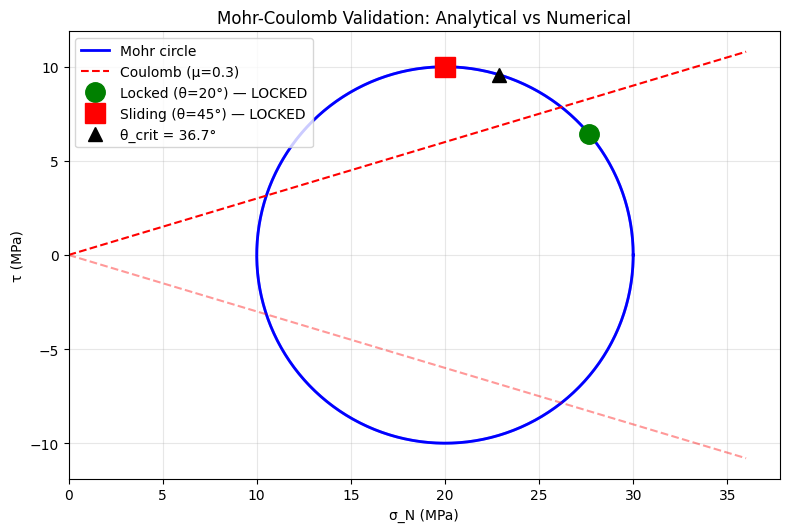

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

theta_range = np.linspace(0, np.pi, 300)
sN_range, tau_range = mohr_tractions(theta_range)
ax.plot(sN_range, tau_range, 'b-', lw=2, label='Mohr circle')
ax.plot(sN_range, -tau_range, 'b-', lw=2, alpha=0.4)

sN_env = np.linspace(0, S1 * 1.2, 100)
ax.plot(sN_env, MU * sN_env, 'r--', lw=1.5, label=f'Coulomb (μ={MU})')
ax.plot(sN_env, -MU * sN_env, 'r--', lw=1.5, alpha=0.4)

ax.plot(sigma_N_locked, tau_locked_val, 'go', ms=14, zorder=5,
        label=f'Locked (θ={np.degrees(THETA_LOCKED):.0f}°) — {locked_result}')
ax.plot(sigma_N_sliding, tau_sliding_val, 'rs', ms=14, zorder=5,
        label=f'Sliding (θ={np.degrees(THETA_SLIDING):.0f}°) — {sliding_result}')

sN_crit, tau_crit = mohr_tractions(theta_crit)
ax.plot(sN_crit, tau_crit, 'k^', ms=10, zorder=5,
        label=f'θ_crit = {np.degrees(theta_crit):.1f}°')

ax.set_xlabel('σ_N (MPa)')
ax.set_ylabel('τ (MPa)')
ax.set_title('Mohr-Coulomb Validation: Analytical vs Numerical')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()